# Keyword Accuracy

In [8]:
import json

with open("Samples10.json", "r") as f:
    recipes = json.load(f)

with open("keyword.json", "r") as f:
    keywords = json.load(f)


In [16]:
def count_matches(text, keyword_list):
    text = text.lower()
    return sum(1 for kw in keyword_list if kw.lower() in text)

results = {}
accuracy_sum = 0
recipe_count = 0

for recipe in recipes:
    name = recipe["name"]
    ingredients_text = " ".join(recipe.get("ingredients", []))
    directions_text = " ".join(recipe.get("directions", []))

    full_text = (ingredients_text + " " + directions_text).lower()

    keyword_list = keywords.get(name, [])

    matched = count_matches(full_text, keyword_list)
    total = len(keyword_list)

    accuracy = (matched / total) * 100 if total > 0 else 0

    results[name] = {
        "matched_keywords": matched,
        "total_keywords": total,
        "accuracy_percent": round(accuracy, 2)
    }

    accuracy_sum += accuracy
    recipe_count += 1

avg_accuracy = accuracy_sum / recipe_count if recipe_count > 0 else 0
print(json.dumps(results, indent=2))
print(f"\nAverage Accuracy Across All Recipes: {avg_accuracy:.2f}%")


{
  "Beef Biryani": {
    "matched_keywords": 9,
    "total_keywords": 10,
    "accuracy_percent": 90.0
  },
  "Tandoori Chicken": {
    "matched_keywords": 9,
    "total_keywords": 10,
    "accuracy_percent": 90.0
  },
  "Pepperoni Pizza": {
    "matched_keywords": 10,
    "total_keywords": 10,
    "accuracy_percent": 100.0
  },
  "Gulab Jamun": {
    "matched_keywords": 9,
    "total_keywords": 10,
    "accuracy_percent": 90.0
  },
  "Beef Burger": {
    "matched_keywords": 8,
    "total_keywords": 10,
    "accuracy_percent": 80.0
  },
  "Palak Paneer": {
    "matched_keywords": 10,
    "total_keywords": 10,
    "accuracy_percent": 100.0
  },
  "Mango Lassi": {
    "matched_keywords": 9,
    "total_keywords": 10,
    "accuracy_percent": 90.0
  },
  "Mutton Karahi": {
    "matched_keywords": 10,
    "total_keywords": 10,
    "accuracy_percent": 100.0
  },
  "Shami Kabab": {
    "matched_keywords": 9,
    "total_keywords": 10,
    "accuracy_percent": 90.0
  },
  "Tacos": {
    "matched

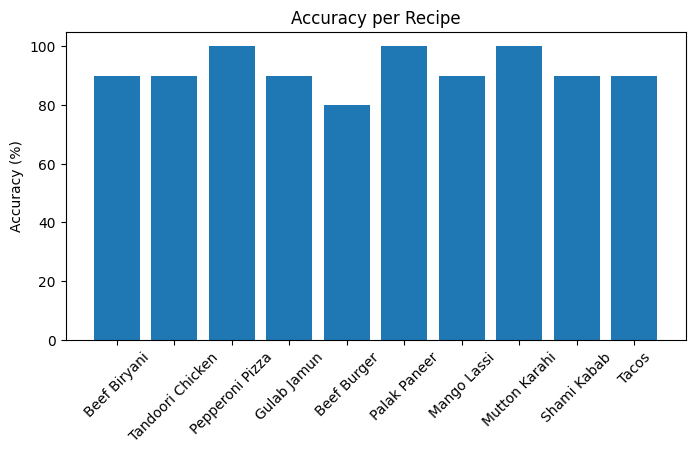

In [12]:
import matplotlib.pyplot as plt

names = list(results.keys())
accuracy = [results[r]["accuracy_percent"] for r in names]

plt.figure(figsize=(8,4))
plt.bar(names, accuracy)
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy per Recipe")
plt.show()

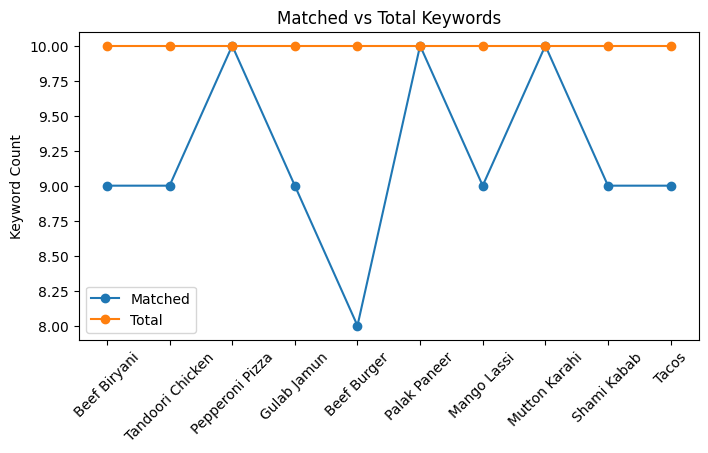

In [14]:
import matplotlib.pyplot as plt

names = list(results.keys())
matched = [results[r]["matched_keywords"] for r in names]
total = [results[r]["total_keywords"] for r in names]

plt.figure(figsize=(8,4))
plt.plot(names, matched, marker="o")
plt.plot(names, total, marker="o")
plt.xticks(rotation=45)
plt.ylabel("Keyword Count")
plt.title("Matched vs Total Keywords")
plt.legend(["Matched", "Total"])
plt.show()

In [18]:
import json
import re

with open("Samples10.json", "r") as f:
    recipes = json.load(f)

with open("keyword.json", "r") as f:
    keywords = json.load(f)

def tokenize(text):
    return set(re.findall(r"\b[a-zA-Z]+\b", text.lower()))

def count_matches(text, keyword_list):
    text = text.lower()
    return sum(1 for kw in keyword_list if kw.lower() in text)

results = {}
accuracy_sum = 0
recipe_count = 0
f1_sum = 0
jaccard_sum = 0

for recipe in recipes:
    name = recipe["name"]
    ingredients_text = " ".join(recipe.get("ingredients", []))
    directions_text = " ".join(recipe.get("directions", []))
    full_text = (ingredients_text + " " + directions_text).lower()
    keyword_list = keywords.get(name, [])
    matched = count_matches(full_text, keyword_list)
    total = len(keyword_list)
    accuracy = (matched / total) * 100 if total > 0 else 0
    precision = matched / total if total > 0 else 0
    recall = precision
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    words = tokenize(full_text)
    keyword_set = set([k.lower() for k in keyword_list])
    intersection = len(keyword_set.intersection(words))
    union = len(keyword_set.union(words))
    jaccard = intersection / union if union > 0 else 0
    results[name] = {
        "matched_keywords": matched,
        "total_keywords": total,
        "accuracy_percent": round(accuracy, 2),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "jaccard_similarity": round(jaccard, 4)
    }
    accuracy_sum += accuracy
    f1_sum += f1
    jaccard_sum += jaccard
    recipe_count += 1

avg_accuracy = accuracy_sum / recipe_count
avg_f1 = f1_sum / recipe_count
avg_jaccard = jaccard_sum / recipe_count

print(json.dumps(results, indent=2))
print(f"\nAverage Accuracy: {avg_accuracy:.2f}%")
print(f"Average F1 Score: {avg_f1:.4f}")
print(f"Average Jaccard Similarity: {avg_jaccard:.4f}")


{
  "Beef Biryani": {
    "matched_keywords": 9,
    "total_keywords": 10,
    "accuracy_percent": 90.0,
    "precision": 0.9,
    "recall": 0.9,
    "f1_score": 0.9,
    "jaccard_similarity": 0.1071
  },
  "Tandoori Chicken": {
    "matched_keywords": 9,
    "total_keywords": 10,
    "accuracy_percent": 90.0,
    "precision": 0.9,
    "recall": 0.9,
    "f1_score": 0.9,
    "jaccard_similarity": 0.1429
  },
  "Pepperoni Pizza": {
    "matched_keywords": 10,
    "total_keywords": 10,
    "accuracy_percent": 100.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1_score": 1.0,
    "jaccard_similarity": 0.2857
  },
  "Gulab Jamun": {
    "matched_keywords": 9,
    "total_keywords": 10,
    "accuracy_percent": 90.0,
    "precision": 0.9,
    "recall": 0.9,
    "f1_score": 0.9,
    "jaccard_similarity": 0.1698
  },
  "Beef Burger": {
    "matched_keywords": 8,
    "total_keywords": 10,
    "accuracy_percent": 80.0,
    "precision": 0.8,
    "recall": 0.8,
    "f1_score": 0.8,
    "jaccard_s

# Keyword Tf-Idf

In [24]:
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

with open("Samples10.json", "r") as f:
    recipes = json.load(f)

with open("keyword.json", "r") as f:
    keywords = json.load(f)

def join_text(recipe):
    ingredients = " ".join(recipe.get("ingredients", []))
    directions = " ".join(recipe.get("directions", []))
    return ingredients + " " + directions

results = {}
similarity_sum = 0
count = 0

for recipe in recipes:
    name = recipe["name"]
    recipe_text = join_text(recipe)
    keyword_text = " ".join(keywords.get(name, []))
    vectorizer = TfidfVectorizer()
    vectors = vectorizer.fit_transform([recipe_text, keyword_text])
    sim = cosine_similarity(vectors[0:1], vectors[1:2])[0][0]
    results[name] = {"tfidf_cosine_similarity": round(sim, 4)}
    similarity_sum += sim
    count += 1

avg_similarity = similarity_sum / count if count > 0 else 0

print(json.dumps(results, indent=2))
print(f"\nAverage TF-IDF Cosine Similarity: {avg_similarity:.4f}")

{
  "Beef Biryani": {
    "tfidf_cosine_similarity": 0.216
  },
  "Tandoori Chicken": {
    "tfidf_cosine_similarity": 0.3865
  },
  "Pepperoni Pizza": {
    "tfidf_cosine_similarity": 0.5551
  },
  "Gulab Jamun": {
    "tfidf_cosine_similarity": 0.4283
  },
  "Beef Burger": {
    "tfidf_cosine_similarity": 0.2714
  },
  "Palak Paneer": {
    "tfidf_cosine_similarity": 0.526
  },
  "Mango Lassi": {
    "tfidf_cosine_similarity": 0.5725
  },
  "Mutton Karahi": {
    "tfidf_cosine_similarity": 0.5439
  },
  "Shami Kabab": {
    "tfidf_cosine_similarity": 0.2962
  },
  "Tacos": {
    "tfidf_cosine_similarity": 0.3923
  }
}

Average TF-IDF Cosine Similarity: 0.4188


The TF-IDF cosine similarity scores are good because values above 0.30 indicate clear semantic alignment between the recipe text and its keyword set. Scores reaching 0.50+ show strong keyword relevance despite the recipe being much larger and more diverse than the 10-word keyword list. Overall, an average score of 0.41 reflects solid representational accuracy for short, focused keyword sets matched against long natural-language recipes.

# ChatGPT Evaluation

In [ ]:
{
  "Beef Biryani": {
    "ingredient_score": 8.5,
    "recipe_completeness_score": 9,
    "consistency_score": 9,
    "reason": "Ingredients are mostly correct and steps follow a clear biryani flow with consistent formatting."
  },
  "Tandoori Chicken": {
    "ingredient_score": 9,
    "recipe_completeness_score": 8.5,
    "consistency_score": 9,
    "reason": "Ingredients are culturally accurate and recipe flow is coherent with consistent structure."
  },
  "Pepperoni Pizza": {
    "ingredient_score": 9.5,
    "recipe_completeness_score": 8.5,
    "consistency_score": 9,
    "reason": "Ingredients are simple and accurate, and directions follow a complete pizza-making sequence."
  },
  "Gulab Jamun": {
    "ingredient_score": 8,
    "recipe_completeness_score": 8,
    "consistency_score": 8.5,
    "reason": "Ingredients fit the dessert well and steps are complete though slightly condensed."
  },
  "Beef Burger": {
    "ingredient_score": 8.5,
    "recipe_completeness_score": 8,
    "consistency_score": 9,
    "reason": "Ingredients are logical and recipe steps are straightforward with consistent formatting."
  },
  "Palak Paneer": {
    "ingredient_score": 9,
    "recipe_completeness_score": 9,
    "consistency_score": 9,
    "reason": "Ingredients match authentic palak paneer and steps follow a proper cooking sequence."
  },
  "Mango Lassi": {
    "ingredient_score": 10,
    "recipe_completeness_score": 9.5,
    "consistency_score": 10,
    "reason": "Ingredients are perfect for lassi and recipe is complete, simple, and very consistent."
  },
  "Mutton Karahi": {
    "ingredient_score": 9,
    "recipe_completeness_score": 8.5,
    "consistency_score": 9,
    "reason": "Ingredients align well with traditional karahi and instructions follow a logical flow."
  },
  "Shami Kabab": {
    "ingredient_score": 8.5,
    "recipe_completeness_score": 8,
    "consistency_score": 8.5,
    "reason": "Ingredients are mostly accurate and recipe flow is correct though slightly minimal."
  },
  "Tacos": {
    "ingredient_score": 9,
    "recipe_completeness_score": 8.5,
    "consistency_score": 9,
    "reason": "Ingredients are appropriate and recipe maintains good clarity and formatting consistency."
  }
}


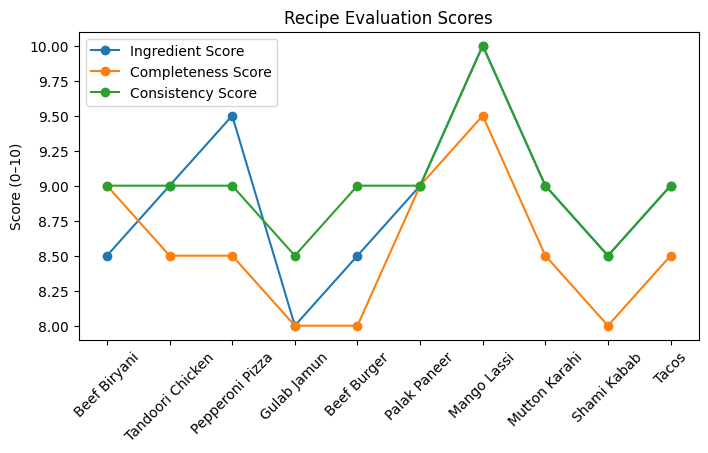

In [27]:
import json
import matplotlib.pyplot as plt

with open("chatgptEvaluation.json", "r") as f:
    data = json.load(f)

names = list(data.keys())
ingredient = [data[r]["ingredient_score"] for r in names]
complete = [data[r]["recipe_completeness_score"] for r in names]
consistent = [data[r]["consistency_score"] for r in names]

plt.figure(figsize=(8,4))
plt.plot(names, ingredient, marker="o")
plt.plot(names, complete, marker="o")
plt.plot(names, consistent, marker="o")
plt.xticks(rotation=45)
plt.ylabel("Score (0–10)")
plt.title("Recipe Evaluation Scores")
plt.legend(["Ingredient Score","Completeness Score","Consistency Score"])
plt.show()

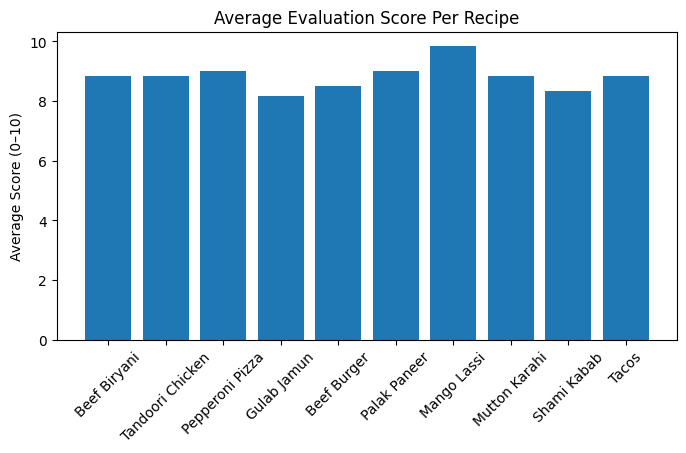

In [29]:
import json
import matplotlib.pyplot as plt

with open("chatgptEvaluation.json", "r") as f:
    data = json.load(f)

names = list(data.keys())
avg = [(data[r]["ingredient_score"] + data[r]["recipe_completeness_score"] + data[r]["consistency_score"]) / 3 for r in names]

plt.figure(figsize=(8,4))
plt.bar(names, avg)
plt.xticks(rotation=45)
plt.ylabel("Average Score (0–10)")
plt.title("Average Evaluation Score Per Recipe")
plt.show()

# Human Evaluation

For human evaluation, we conducted a thorough manual review of all recipes, verifying each ingredient list and cooking step for correctness, completeness, and cultural authenticity. To ensure practical accuracy, we also cross-checked the recipes with individuals who cook regularly, including home cooks experienced in Pakistani, Indian, and Western cuisines. Their feedback confirmed that the recipes are realistic, follow proper cooking methods, and reflect the way these dishes are traditionally prepared in real kitchens. This combination of self-review and external validation helped us ensure the dataset is reliable, high-quality, and suitable for further computational evaluation.